In [18]:
# ============================================================
# E-COMMERCE CUSTOMER SEGMENTATION USING RFM ANALYSIS
# Dataset: UCI Online Retail (500K+ transactions, 2010-2011)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime

print("All libraries imported successfully.")

All libraries imported successfully.


In [19]:
# ============================================================
# DATA LOADING & FIRST LOOK
# ============================================================

df = pd.read_excel('Online Retail.xlsx', sheet_name='Online Retail')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Data Types:")
print(df.dtypes)

print("\nBasic Statistics:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (541909, 8)

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Column Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Basic Statistics:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303



Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [20]:
# ============================================================
# PHASE 1 — DATA CLEANING
# ============================================================

df_clean = df.copy()

# --- Step 1: Drop missing CustomerIDs (can't do RFM without them) ---
before = len(df_clean)
df_clean = df_clean.dropna(subset=['CustomerID'])
print(f"Dropped missing CustomerIDs: {before - len(df_clean):,} rows removed")

# --- Step 2: Drop missing Descriptions ---
df_clean = df_clean.dropna(subset=['Description'])
print(f"After dropping missing Descriptions: {len(df_clean):,} rows remain")

# --- Step 3: Remove returns and cancellations ---
# Negative quantity = returns, InvoiceNo starting with C = cancelled orders
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f"After removing returns/cancellations: {len(df_clean):,} rows remain")

# --- Step 4: Fix data types ---
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# --- Step 5: Create TotalPrice column ---
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# --- Final summary ---
print(f"\nFinal clean dataset: {len(df_clean):,} rows")
print(f"Unique customers: {df_clean['CustomerID'].nunique():,}")
print(f"Unique invoices: {df_clean['InvoiceNo'].nunique():,}")
print(f"Date range: {df_clean['InvoiceDate'].min().date()} to {df_clean['InvoiceDate'].max().date()}")
print(f"Total revenue in dataset: £{df_clean['TotalPrice'].sum():,.2f}")

Dropped missing CustomerIDs: 135,080 rows removed
After dropping missing Descriptions: 406,829 rows remain
After removing returns/cancellations: 397,884 rows remain

Final clean dataset: 397,884 rows
Unique customers: 4,338
Unique invoices: 18,532
Date range: 2010-12-01 to 2011-12-09
Total revenue in dataset: £8,911,407.90


In [21]:
# ============================================================
# PHASE 2 — RFM CALCULATION
# Recency, Frequency, Monetary value per customer
# ============================================================

# --- Reference date: 1 day after last transaction ---
# This is standard practice in RFM analysis
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date for Recency calculation: {snapshot_date.date()}")

# --- Calculate RFM metrics per customer ---
rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print(f"\nRFM Table (first 5 rows):")
display(rfm.head())

print(f"\nRFM Summary Statistics:")
display(rfm.describe().round(2))

# --- Score each metric on a scale of 1-4 ---
# Recency: lower days = better = higher score (so we reverse it)
# Frequency & Monetary: higher = better = higher score
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1, 2, 3, 4])

# --- Combine into single RFM score ---
rfm['RFM_Score'] = (rfm['R_Score'].astype(int) +
                    rfm['F_Score'].astype(int) +
                    rfm['M_Score'].astype(int))

print(f"\nRFM Score Distribution:")
print(rfm['RFM_Score'].value_counts().sort_index())

Reference date for Recency calculation: 2011-12-10

RFM Table (first 5 rows):


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40



RFM Summary Statistics:


,CustomerID,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2054.27
std,1721.81,100.01,7.70,8989.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,307.41
50%,15299.50,51.00,2.00,674.48
75%,16778.75,142.00,5.00,1661.74
max,18287.00,374.00,209.00,280206.02



RFM Score Distribution:
RFM_Score
3     303
4     504
5     484
6     504
7     432
8     432
9     411
10    391
11    387
12    490
Name: count, dtype: int64


In [22]:
# ============================================================
# PHASE 3 — CUSTOMER SEGMENTATION
# Mapping RFM scores to business segments
# ============================================================

def segment_customer(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']
    score = row['RFM_Score']

    if r == 4 and f == 4 and m == 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r == 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r == 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 3 and m >= 3:
        return "Can't Lose Them"
    elif r <= 2 and f <= 2:
        return 'Hibernating'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# --- Segment summary ---
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count = ('CustomerID', 'count'),
    Avg_Recency    = ('Recency', 'mean'),
    Avg_Frequency  = ('Frequency', 'mean'),
    Avg_Monetary   = ('Monetary', 'mean'),
    Total_Revenue  = ('Monetary', 'sum')
).round(2).reset_index()

segment_summary['Revenue_Pct'] = (
    segment_summary['Total_Revenue'] /
    segment_summary['Total_Revenue'].sum() * 100
).round(2)

segment_summary = segment_summary.sort_values('Total_Revenue', ascending=False)

print("Customer Segment Summary:")
display(segment_summary)

Customer Segment Summary:


,Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Pct
2,Champions,490,7.43,15.51,9050.50,4434743.73,49.76
4,Loyal Customers,1033,22.64,5.22,2097.42,2166631.42,24.31
0,At Risk,465,84.78,4.35,1655.09,769616.49,8.64
3,Hibernating,1504,186.57,1.25,510.07,767146.84,8.61
7,Recent Customers,234,9.99,1.56,1229.38,287674.57,3.23
1,Can't Lose Them,88,201.77,4.55,2663.57,234393.79,2.63
5,Needs Attention,442,71.28,1.65,331.93,146713.31,1.65
6,Potential Loyalists,82,33.80,1.73,1274.24,104487.75,1.17


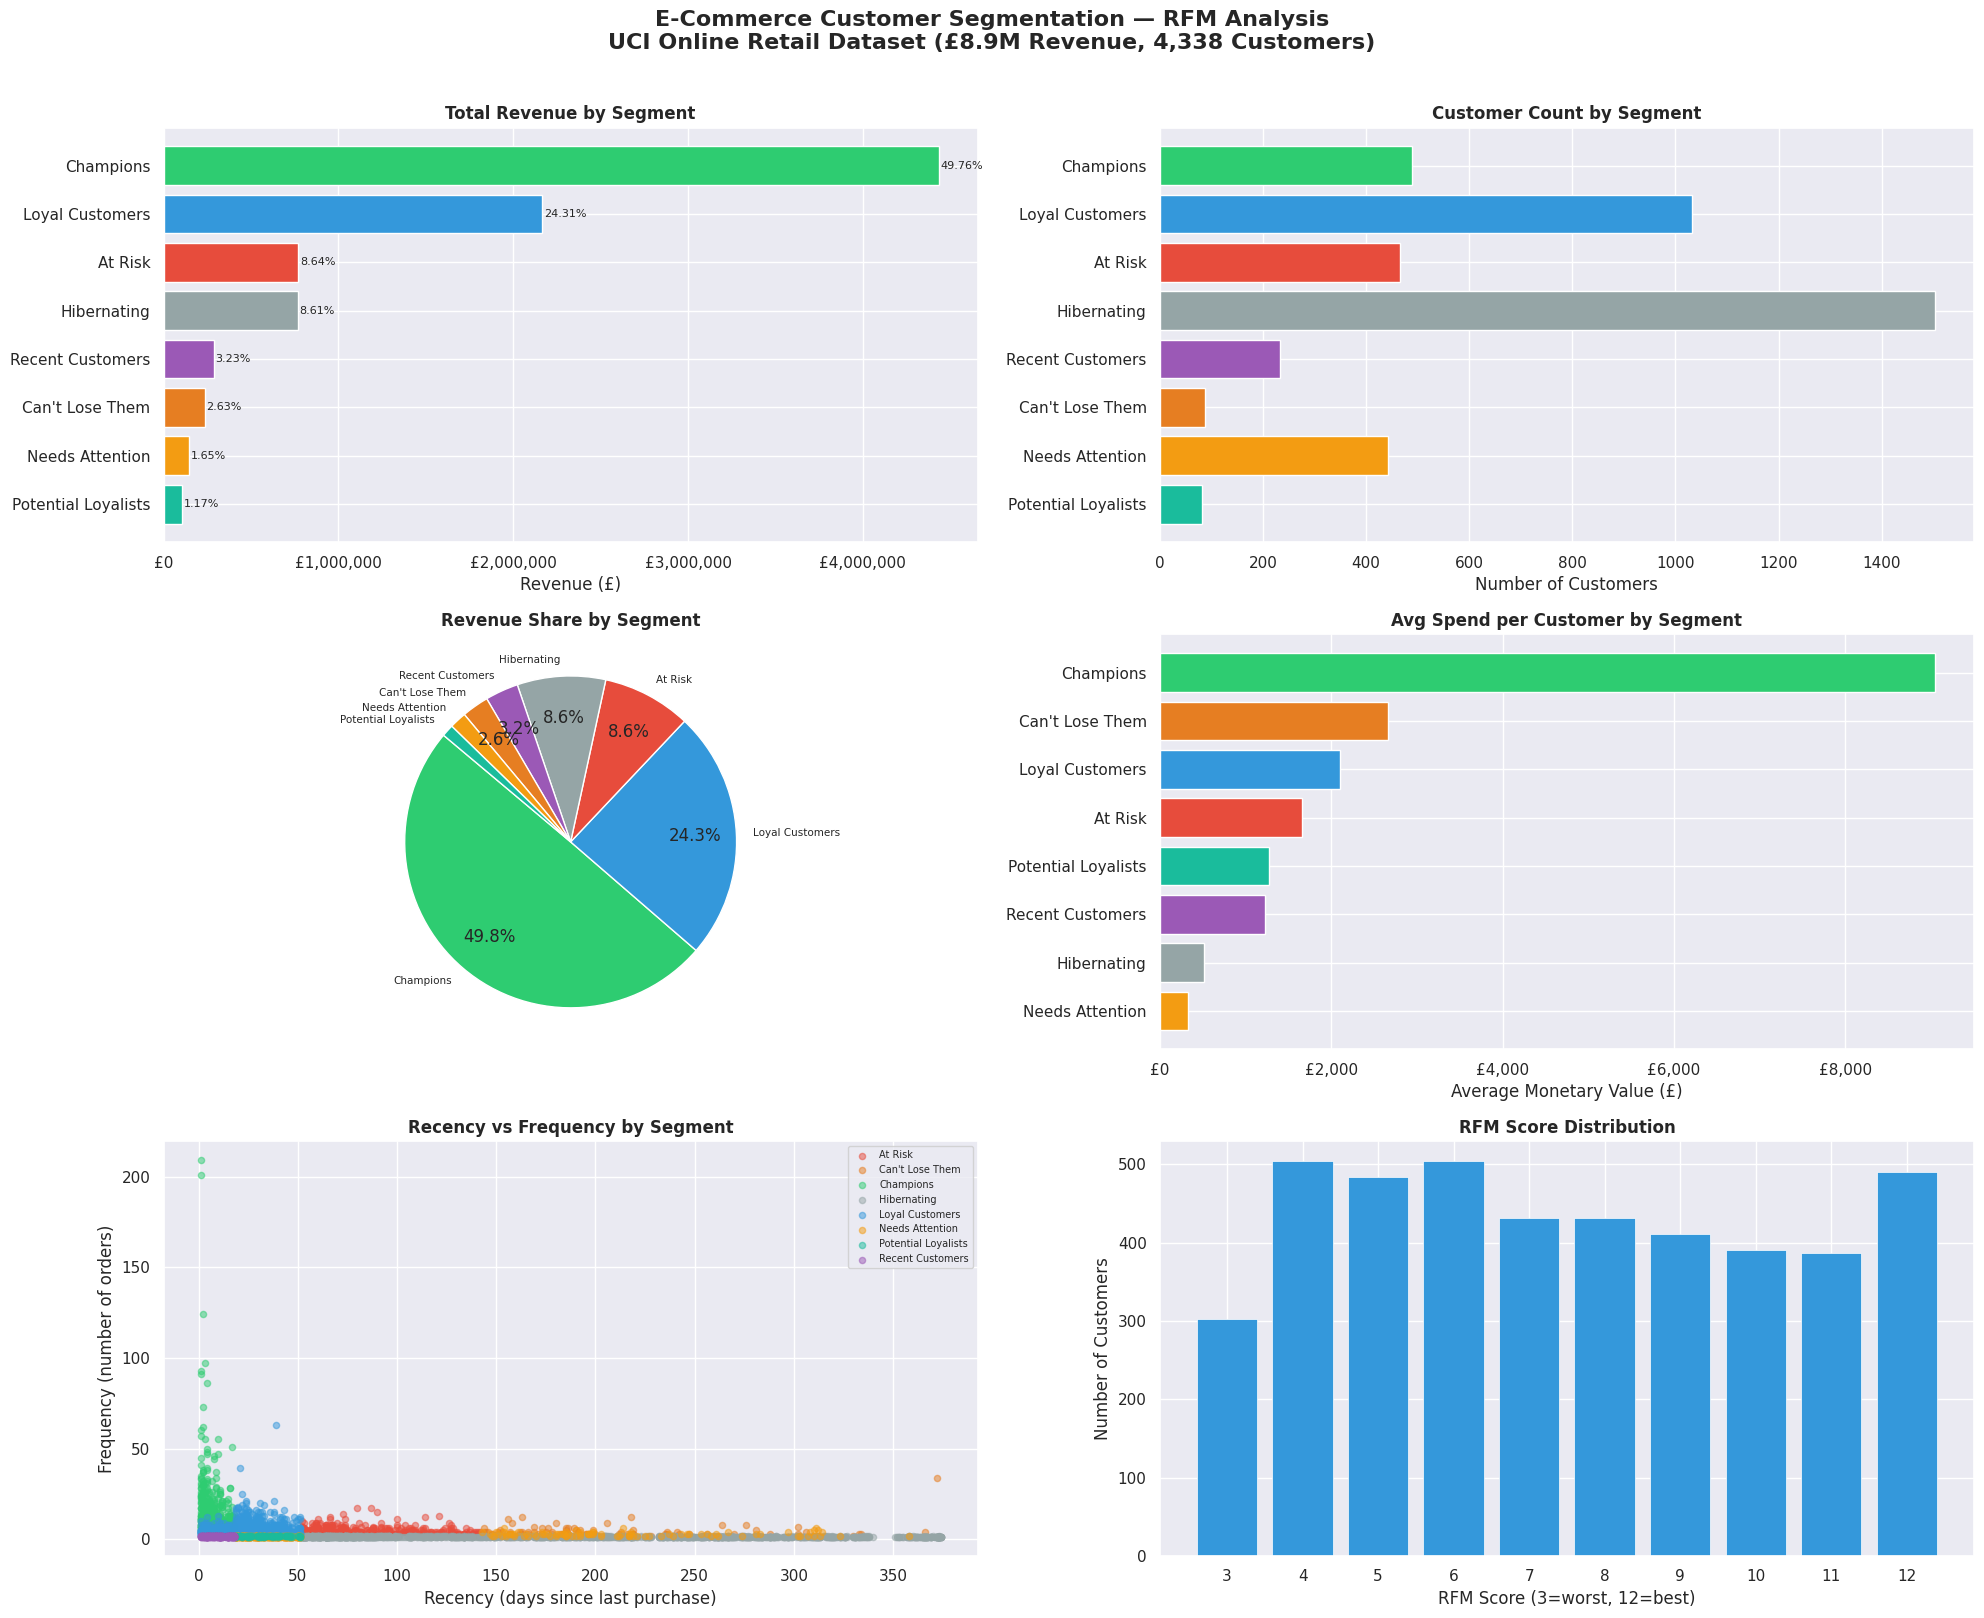

In [23]:
# ============================================================
# PHASE 4 — VISUALIZATIONS
# ============================================================

import seaborn as sns
import matplotlib.ticker as ticker

sns.set_theme(style='darkgrid')
colors = {
    'Champions':          '#2ECC71',
    'Loyal Customers':    '#3498DB',
    'At Risk':            '#E74C3C',
    'Hibernating':        '#95A5A6',
    'Recent Customers':   '#9B59B6',
    "Can't Lose Them":    '#E67E22',
    'Needs Attention':    '#F39C12',
    'Potential Loyalists':'#1ABC9C'
}
segment_colors = segment_summary['Segment'].map(colors)

fig = plt.figure(figsize=(20, 16))
fig.suptitle("E-Commerce Customer Segmentation — RFM Analysis\nUCI Online Retail Dataset (£8.9M Revenue, 4,338 Customers)",
             fontsize=16, fontweight='bold', y=1.01)

# ── CHART 1: Revenue by Segment (horizontal bar) ─────────────
ax1 = fig.add_subplot(3, 2, 1)
bars = ax1.barh(segment_summary['Segment'],
                segment_summary['Total_Revenue'],
                color=segment_colors)
ax1.set_title("Total Revenue by Segment", fontweight='bold')
ax1.set_xlabel("Revenue (£)")
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for bar, pct in zip(bars, segment_summary['Revenue_Pct']):
    ax1.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
             f'{pct}%', va='center', fontsize=8)
ax1.invert_yaxis()

# ── CHART 2: Customer Count by Segment (horizontal bar) ──────
ax2 = fig.add_subplot(3, 2, 2)
ax2.barh(segment_summary['Segment'],
         segment_summary['Customer_Count'],
         color=segment_colors)
ax2.set_title("Customer Count by Segment", fontweight='bold')
ax2.set_xlabel("Number of Customers")
ax2.invert_yaxis()

# ── CHART 3: Revenue share pie chart ─────────────────────────
ax3 = fig.add_subplot(3, 2, 3)
wedge_colors = [colors[s] for s in segment_summary['Segment']]
wedges, texts, autotexts = ax3.pie(
    segment_summary['Revenue_Pct'],
    labels=segment_summary['Segment'],
    colors=wedge_colors,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    startangle=140,
    pctdistance=0.75
)
for text in texts:
    text.set_fontsize(7.5)
ax3.set_title("Revenue Share by Segment", fontweight='bold')

# ── CHART 4: Avg Monetary Value by Segment ───────────────────
ax4 = fig.add_subplot(3, 2, 4)
sorted_monetary = segment_summary.sort_values('Avg_Monetary', ascending=True)
ax4.barh(sorted_monetary['Segment'],
         sorted_monetary['Avg_Monetary'],
         color=[colors[s] for s in sorted_monetary['Segment']])
ax4.set_title("Avg Spend per Customer by Segment", fontweight='bold')
ax4.set_xlabel("Average Monetary Value (£)")
ax4.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# ── CHART 5: Recency vs Frequency scatter ────────────────────
ax5 = fig.add_subplot(3, 2, 5)
for segment, group in rfm.groupby('Segment'):
    ax5.scatter(group['Recency'], group['Frequency'],
                color=colors.get(segment, 'white'),
                label=segment, alpha=0.5, s=20)
ax5.set_title("Recency vs Frequency by Segment", fontweight='bold')
ax5.set_xlabel("Recency (days since last purchase)")
ax5.set_ylabel("Frequency (number of orders)")
ax5.legend(fontsize=7, loc='upper right')

# ── CHART 6: RFM Score Distribution ──────────────────────────
ax6 = fig.add_subplot(3, 2, 6)
rfm_dist = rfm['RFM_Score'].value_counts().sort_index()
ax6.bar(rfm_dist.index, rfm_dist.values, color='#3498DB', edgecolor='white', linewidth=0.5)
ax6.set_title("RFM Score Distribution", fontweight='bold')
ax6.set_xlabel("RFM Score (3=worst, 12=best)")
ax6.set_ylabel("Number of Customers")
ax6.set_xticks(range(3, 13))

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# FINAL SUMMARY — BUSINESS RECOMMENDATIONS
# ============================================================

total_revenue = rfm['Monetary'].sum()
champion_revenue = rfm[rfm['Segment'] == 'Champions']['Monetary'].sum()
at_risk_revenue = rfm[rfm['Segment'] == 'At Risk']['Monetary'].sum()
cant_lose_revenue = rfm[rfm["Segment"] == "Can't Lose Them"]['Monetary'].sum()
hibernating_count = len(rfm[rfm['Segment'] == 'Hibernating'])

summary = """
╔══════════════════════════════════════════════════════════════════╗
║         E-COMMERCE RFM ANALYSIS — BUSINESS CONCLUSIONS           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET OVERVIEW                                                ║
║  Total Revenue:       £8,911,407.90                              ║
║  Total Customers:     4,338                                      ║
║  Total Invoices:      18,532                                     ║
║  Date Range:          Dec 2010 — Dec 2011                        ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  KEY FINDINGS                                                    ║
║                                                                  ║
║  1. CHAMPIONS (490 customers = 49.76% of revenue)                ║
║     Just 11% of customers generate half of all revenue.          ║
║     Protecting this group is the single highest priority.        ║
║                                                                  ║
║  2. AT RISK (465 customers = 8.64% of revenue)                   ║
║     £769K in revenue from customers who are drifting away.       ║
║     Last purchase avg 84 days ago — intervention needed now.     ║
║                                                                  ║
║  3. CAN'T LOSE THEM (88 customers = 2.63% of revenue)            ║
║     Former high-value customers going cold (201 days absent).    ║
║     £234K revenue at risk — highest priority for personal        ║
║     outreach and win-back campaigns.                             ║
║                                                                  ║
║  4. HIBERNATING (1,504 customers = 8.61% of revenue)             ║
║     Largest segment by count but nearly lost.                    ║
║     186 days avg since last purchase — one last re-engagement    ║
║     attempt recommended before writing off.                      ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  MARKETING RECOMMENDATIONS BY SEGMENT                            ║
║                                                                  ║
║  Champions        → VIP rewards, early access, loyalty perks     ║
║  Loyal Customers  → Upsell campaigns, bundle offers              ║
║  At Risk          → Win-back emails, limited time discounts      ║
║  Can't Lose Them  → Personal outreach, premium re-engagement     ║
║  Recent Customers → Onboarding emails, first repeat purchase     ║
║                     incentive                                    ║
║  Hibernating      → One final campaign, then reallocate budget   ║
║  Needs Attention  → Low cost automated nudge campaigns           ║
║  Potential        → nurture with relevant product                ║
║  Loyalists          recommendations                              ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  VERDICT                                                         ║
║  The business is heavily dependent on a small Champions          ║
║  segment. Diversifying revenue across Loyal and At Risk          ║
║  segments through targeted retention strategies should be        ║
║  the immediate strategic priority.                               ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════╗
║         E-COMMERCE RFM ANALYSIS — BUSINESS CONCLUSIONS           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET OVERVIEW                                                ║
║  Total Revenue:       £8,911,407.90                              ║
║  Total Customers:     4,338                                      ║
║  Total Invoices:      18,532                                     ║
║  Date Range:          Dec 2010 — Dec 2011                        ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  KEY FINDINGS                                                    ║
║                                                                  ║
║  1. CHAMPIONS (490 customers = 